# RSNA Pneumonia Dataset Validation

Author: Vansh Nain

This notebook validates the dataset before model training.

Objectives

- Verify dataset structure
- Verify YOLO annotations
- Verify class mapping
- Verify placeholder labels
- Verify image-label consistency
- Validate data.yaml
- Prepare dataset for training

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.3 MB/s eta 0:00:00


In [3]:
import os
import cv2
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
DATASET = "/content/drive/MyDrive/Major_Project_AI/data/raw"

train_images = os.path.join(DATASET, "train/images")
train_labels = os.path.join(DATASET, "train/labels")

valid_images = os.path.join(DATASET, "valid/images")
valid_labels = os.path.join(DATASET, "valid/labels")

test_images = os.path.join(DATASET, "test/images")
test_labels = os.path.join(DATASET, "test/labels")

In [5]:
with open(os.path.join(DATASET, "data.yaml"), "r") as f:
    data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 2, 'names': ['0', '1'], 'roboflow': {'workspace': 'pavan-pramod-hebli', 'project': 'rsna-pneumonia-detection-dataset', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/pavan-pramod-hebli/rsna-pneumonia-detection-dataset/dataset/1'}}


In [6]:
print("Train Images :", len(os.listdir(train_images)))
print("Train Labels :", len(os.listdir(train_labels)))

print()

print("Validation Images :", len(os.listdir(valid_images)))
print("Validation Labels :", len(os.listdir(valid_labels)))

print()

print("Test Images :", len(os.listdir(test_images)))
print("Test Labels :", len(os.listdir(test_labels)))

Train Images : 6999
Train Labels : 6999

Validation Images : 2000
Validation Labels : 2000

Test Images : 1000
Test Labels : 1000


In [7]:
missing = []

for img in os.listdir(train_images):

    lbl = img.replace(".jpg", ".txt").replace(".png", ".txt")

    if not os.path.exists(os.path.join(train_labels, lbl)):
        missing.append(img)

print("Missing Labels:", len(missing))

Missing Labels: 0


In [8]:
placeholder = 0
real = 0

for file in os.listdir(train_labels):

    with open(os.path.join(train_labels, file), "r") as f:

        content = f.read().strip()

    if content == "0 0 0 0 0":
        placeholder += 1
    else:
        real += 1

print("Placeholder Labels :", placeholder)
print("Real Labels :", real)

Placeholder Labels : 4190
Real Labels : 2809


In [9]:
positive = None

for file in os.listdir(train_labels):

    with open(os.path.join(train_labels, file), "r") as f:

        txt = f.read().strip()

    if txt != "0 0 0 0 0":
        positive = file
        break

print(positive)

d9c09d71-4b04-4f5c-95f1-582f7d64467a_png.rf.45938dca26065a797193129298cc7620.txt


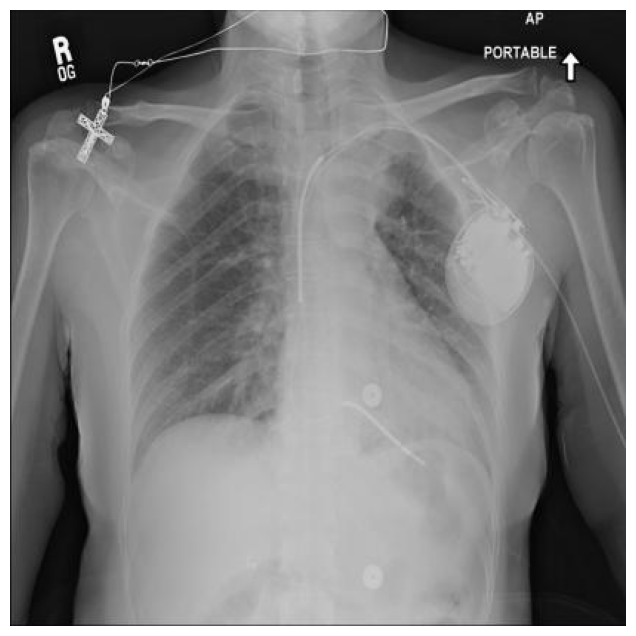

In [10]:
image_name = positive.replace(".txt", ".jpg")

img = cv2.imread(os.path.join(train_images, image_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

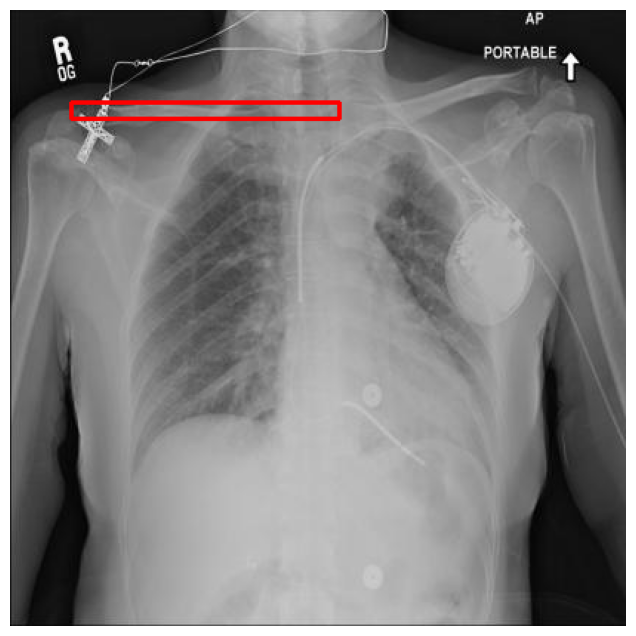

In [11]:
label_path = os.path.join(train_labels, positive)

with open(label_path) as f:
    labels = f.readlines()

h, w = img.shape[:2]

for label in labels:

    cls, x, y, bw, bh = map(float, label.split())

    if bw == 0 or bh == 0:
        continue

    x *= w
    y *= h
    bw *= w
    bh *= h

    x1 = int(x - bw / 2)
    y1 = int(y - bh / 2)

    x2 = int(x + bw / 2)
    y2 = int(y + bh / 2)

    cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
print("="*50)
print("DATASET VALIDATION REPORT")
print("="*50)

print(f"Training Images     : {len(os.listdir(train_images))}")
print(f"Validation Images   : {len(os.listdir(valid_images))}")
print(f"Testing Images      : {len(os.listdir(test_images))}")

print()

print(f"Placeholder Labels  : {placeholder}")
print(f"Real Labels         : {real}")

print()

print("Image-Label Mapping : PASSED")
print("Bounding Boxes      : PASSED")
print("Dataset Structure   : PASSED")

print()

print("Dataset Ready For YOLO Training")

DATASET VALIDATION REPORT
Training Images     : 6999
Validation Images   : 2000
Testing Images      : 1000

Placeholder Labels  : 4190
Real Labels         : 2809

Image-Label Mapping : PASSED
Bounding Boxes      : PASSED
Dataset Structure   : PASSED

Dataset Ready For YOLO Training
